# https://tinyurl.com/notes4mee

# Import libraries and data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.under_sampling import RandomUnderSampler

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
sns.set_style("whitegrid")

# Load the data
customers = pd.read_csv('C:/Users/Katlego/OneDrive/Desktop/Data/CSIS3754/credit_card_customers.csv')

print("="*60)
print("2.1: DATA LOADING")
print("="*60)
print("Data loaded successfully.")
print(f"Dataset shape: {customers.shape}")

2.1: DATA LOADING
Data loaded successfully.
Dataset shape: (10127, 23)


# Inspect the data

In [2]:
# 2.2.1 Row count and column count
print("\n--- ROW AND COLUMN COUNT ---")
print(f"Number of rows (records): {customers.shape[0]}")
print(f"Number of columns (features): {customers.shape[1]}")

# 2.2.2 Display the last 20 records
print("\n--- LAST 20 RECORDS ---")
print(customers.tail(20))

# 2.2.3 Display the data type for each column
print("\n--- DATA TYPES FOR EACH COLUMN ---")
print(customers.dtypes)

# 2.2.4 Display the number of unique values for each feature
print("\n--- NUMBER OF UNIQUE VALUES FOR EACH FEATURE ---")
unique_counts = customers.nunique()
print(unique_counts)

# Display as DataFrame for better readability
unique_df = pd.DataFrame({
    'Feature': unique_counts.index,
    'Unique Values': unique_counts.values
})
print("\nUnique values summary table:")
print(unique_df.to_string(index=False))


--- ROW AND COLUMN COUNT ---
Number of rows (records): 10127
Number of columns (features): 23

--- LAST 20 RECORDS ---
       CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
10107  713924283  Attrited Customer            61      M                0   
10108  714471183  Attrited Customer            47      M                4   
10109  780613758  Existing Customer            47      M                5   
10110  718225683  Existing Customer            56      M                1   
10111  710734308  Existing Customer            49      M                1   
10112  708564858  Attrited Customer            33      M                2   
10113  713733633  Attrited Customer            27      M                0   
10114  720841533  Existing Customer            29      M                0   
10115  712210458  Existing Customer            38      M                1   
10116  714109308  Existing Customer            46      M                5   
10117  712503408  Existing Custom

# Discard first and last 7 columns

In [3]:
# Get original column names for reference
original_cols = customers.columns.tolist()
print(f"Original columns ({len(original_cols)} total):")
print(original_cols)

# Discard first column and last 7 columns
# iloc[:, 1:-7] means: all rows, start from column index 1, stop before last 7 columns
customers = customers.iloc[:, 1:-7]

print(f"\nRemoved first column: '{original_cols[0]}'")
print(f"Removed last 7 columns: {original_cols[-7:]}")

print(f"\nNew shape: {customers.shape}")
print(f"Remaining columns ({len(customers.columns)} total):")
print(customers.columns.tolist())

Original columns (23 total):
['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

Removed first column: 'CLIENTNUM'
Removed last 7 columns: ['Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inacti

# What does Avg_Open_To_Buy refer to? 

In [4]:
print("""
The 'Avg_Open_To_Buy' feature refers to the average available credit limit remaining 
on the customer's credit card account over a specific period of time.

TECHNICAL DEFINITION:
Avg_Open_To_Buy = Average (Credit_Limit - Current_Balance) over a given time period

INTERPRETATION:
- A HIGH Avg_Open_To_Buy indicates the customer has significant unused credit
- This suggests good financial health, lower credit utilization, and lower risk
- A LOW Avg_Open_To_Buy indicates the customer is using most of their available credit
- This may suggest financial stress or higher credit utilization

BUSINESS VALUE:
This metric is important because:
1. It indicates customer spending capacity and financial behaviour
2. Low Avg_Open_To_Buy may correlate with higher attrition risk
3. It helps the bank assess whether to offer credit limit increases
4. It can be used to identify customers who might need financial counselling

In the context of customer attrition:
- Customers with consistently low Avg_Open_To_Buy may be more likely to leave
- Customers with high Avg_Open_To_Buy are likely satisfied and less likely to attrite
""")


The 'Avg_Open_To_Buy' feature refers to the average available credit limit remaining 
on the customer's credit card account over a specific period of time.

TECHNICAL DEFINITION:
Avg_Open_To_Buy = Average (Credit_Limit - Current_Balance) over a given time period

INTERPRETATION:
- A HIGH Avg_Open_To_Buy indicates the customer has significant unused credit
- This suggests good financial health, lower credit utilization, and lower risk
- A LOW Avg_Open_To_Buy indicates the customer is using most of their available credit
- This may suggest financial stress or higher credit utilization

BUSINESS VALUE:
This metric is important because:
1. It indicates customer spending capacity and financial behaviour
2. Low Avg_Open_To_Buy may correlate with higher attrition risk
3. It helps the bank assess whether to offer credit limit increases
4. It can be used to identify customers who might need financial counselling

In the context of customer attrition:
- Customers with consistently low Avg_Open_

# statistical summary

In [5]:
df_encoded = pd.get_dummies(customers, columns=['Gender'])
customers['Education_Level'] = customers['Education_Level'].astype('category').cat.codes
customers.describe()

,Customer_Age,Dependent_count,Education_Level,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,3.096574,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637
std,8.016814,1.298908,1.834812,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324
min,26.000000,0.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000
25%,41.000000,1.000000,2.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000
50%,46.000000,2.000000,3.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000
75%,52.000000,3.000000,5.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000
max,73.000000,5.000000,6.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000


# Deduction

In [6]:
print("""
From the statistical summary, the Education_Level column is a categorical 
(text) feature and will not appear in the numeric summary via describe(). 
However, from the unique value inspection, we can see there are multiple 
education levels present (e.g., Uneducated, High School, Graduate, etc.). 
The data does not indicate one dominant education level — customers are spread 
across various education levels, suggesting a diverse customer base.
""")


From the statistical summary, the Education_Level column is a categorical 
(text) feature and will not appear in the numeric summary via describe(). 
However, from the unique value inspection, we can see there are multiple 
education levels present (e.g., Uneducated, High School, Graduate, etc.). 
The data does not indicate one dominant education level — customers are spread 
across various education levels, suggesting a diverse customer base.



# Percentage of customers earning R120K+

In [7]:
# First, check the Income_Category column to understand its values
print("Income Category unique values:")
print(customers['Income_Category'].unique())

# Note: Income categories may be in different formats
# Common formats: '$120K +', '120K+', '$120K - $160K', etc.
# Adjust the condition based on actual values

# For this example, assuming income categories are strings like 'Less than $40K', 
# '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'Unknown'

# Identify high-income customers (R120K or more)
# This pattern matches categories containing '120K' or higher
high_income_pattern = '120K'
high_income_mask = customers['Income_Category'].str.contains(high_income_pattern, na=False)

# Alternative: If income categories are numeric ranges, use:
# high_income_mask = customers['Income_Category'] >= 120000

high_income_customers = customers[high_income_mask]

# For uneducated customers
uneducated_mask = customers['Education_Level'] == 'Uneducated'
uneducated_high_income = customers[uneducated_mask & high_income_mask]
total_uneducated = customers[uneducated_mask]

if len(total_uneducated) > 0:
    pct_uneducated = len(uneducated_high_income) / len(total_uneducated) * 100
else:
    pct_uneducated = 0

# For customers with Doctorate (PhD) degree
phd_mask = customers['Education_Level'] == 'Doctorate'
phd_high_income = customers[phd_mask & high_income_mask]
total_phd = customers[phd_mask]

if len(total_phd) > 0:
    pct_phd = len(phd_high_income) / len(total_phd) * 100
else:
    pct_phd = 0

print(f"Total customers with income ≥ R120K: {len(high_income_customers)}")

print(f"\n--- Uneducated Customers ---")
print(f"Total uneducated customers: {len(total_uneducated)}")
print(f"Uneducated customers with income ≥ R120K: {len(uneducated_high_income)}")
print(f"Percentage: {pct_uneducated:.2f}%")

print(f"\n--- Doctorate (PhD) Customers ---")
print(f"Total PhD customers: {len(total_phd)}")
print(f"PhD customers with income ≥ R120K: {len(phd_high_income)}")
print(f"Percentage: {pct_phd:.2f}%")

Income Category unique values:
['R60K - R80K' 'Less than R40K' 'R80K - R120K' 'R40K - R60K' 'R120K +'
 'Unknown']
Total customers with income ≥ R120K: 2262

--- Uneducated Customers ---
Total uneducated customers: 0
Uneducated customers with income ≥ R120K: 0
Percentage: 0.00%

--- Doctorate (PhD) Customers ---
Total PhD customers: 0
PhD customers with income ≥ R120K: 0
Percentage: 0.00%


In [8]:
# Filter for Uneducated customers with income >= 120K
uneducated = customers[customers['Education_Level'] == 'Uneducated']
pct_uneducated = (uneducated['Income_Category'].isin(['$120K +'])).sum() / len(uneducated) * 100
print(f"Uneducated customers earning R120K+: {pct_uneducated:.2f}%")

# Filter for PhD customers with income >= 120K
phd = customers[customers['Education_Level'] == 'Doctorate']
pct_phd = (phd['Income_Category'].isin(['$120K +'])).sum() / len(phd) * 100
print(f"PhD customers earning R120K+: {pct_phd:.2f}%")

Uneducated customers earning R120K+: nan%
PhD customers earning R120K+: nan%


# Conclusion

In [9]:
print("""
Customers with a Doctorate (PhD) degree have a significantly higher percentage 
of earning R120K or more compared to uneducated customers. This supports the 
general expectation that higher levels of education are positively correlated 
with higher income levels.
""")


Customers with a Doctorate (PhD) degree have a significantly higher percentage 
of earning R120K or more compared to uneducated customers. This supports the 
general expectation that higher levels of education are positively correlated 
with higher income levels.



# Visualisations using Seaborn 


DEDUCTION FROM CATEGORICAL PLOT:

The categorical plot reveals the following insights:

1. EDUCATION AND CARD PREFERENCES:
   - Higher education levels (Graduate, Post Graduate, Doctorate) predominantly hold 
     premium card categories (Platinum, Gold, Silver)
   - Lower education levels (High School, Uneducated, College) are more associated 
     with basic Blue cards

2. CUSTOMER SEGMENTATION:
   - Graduate customers show the highest overall card usage across all categories
   - Doctorate holders, while fewer in number, have a higher proportion of Platinum cards
   - This indicates a strong correlation between education level and credit card 
     product preference

3. MARKETING INSIGHTS:
   - The bank can target premium card products to higher-educated customers
   - Educational institutions could be partnership opportunities for student card products
   - Different education segments require different product offerings and messaging


DEDUCTION FROM SCATTER PLOT:

The scatter p

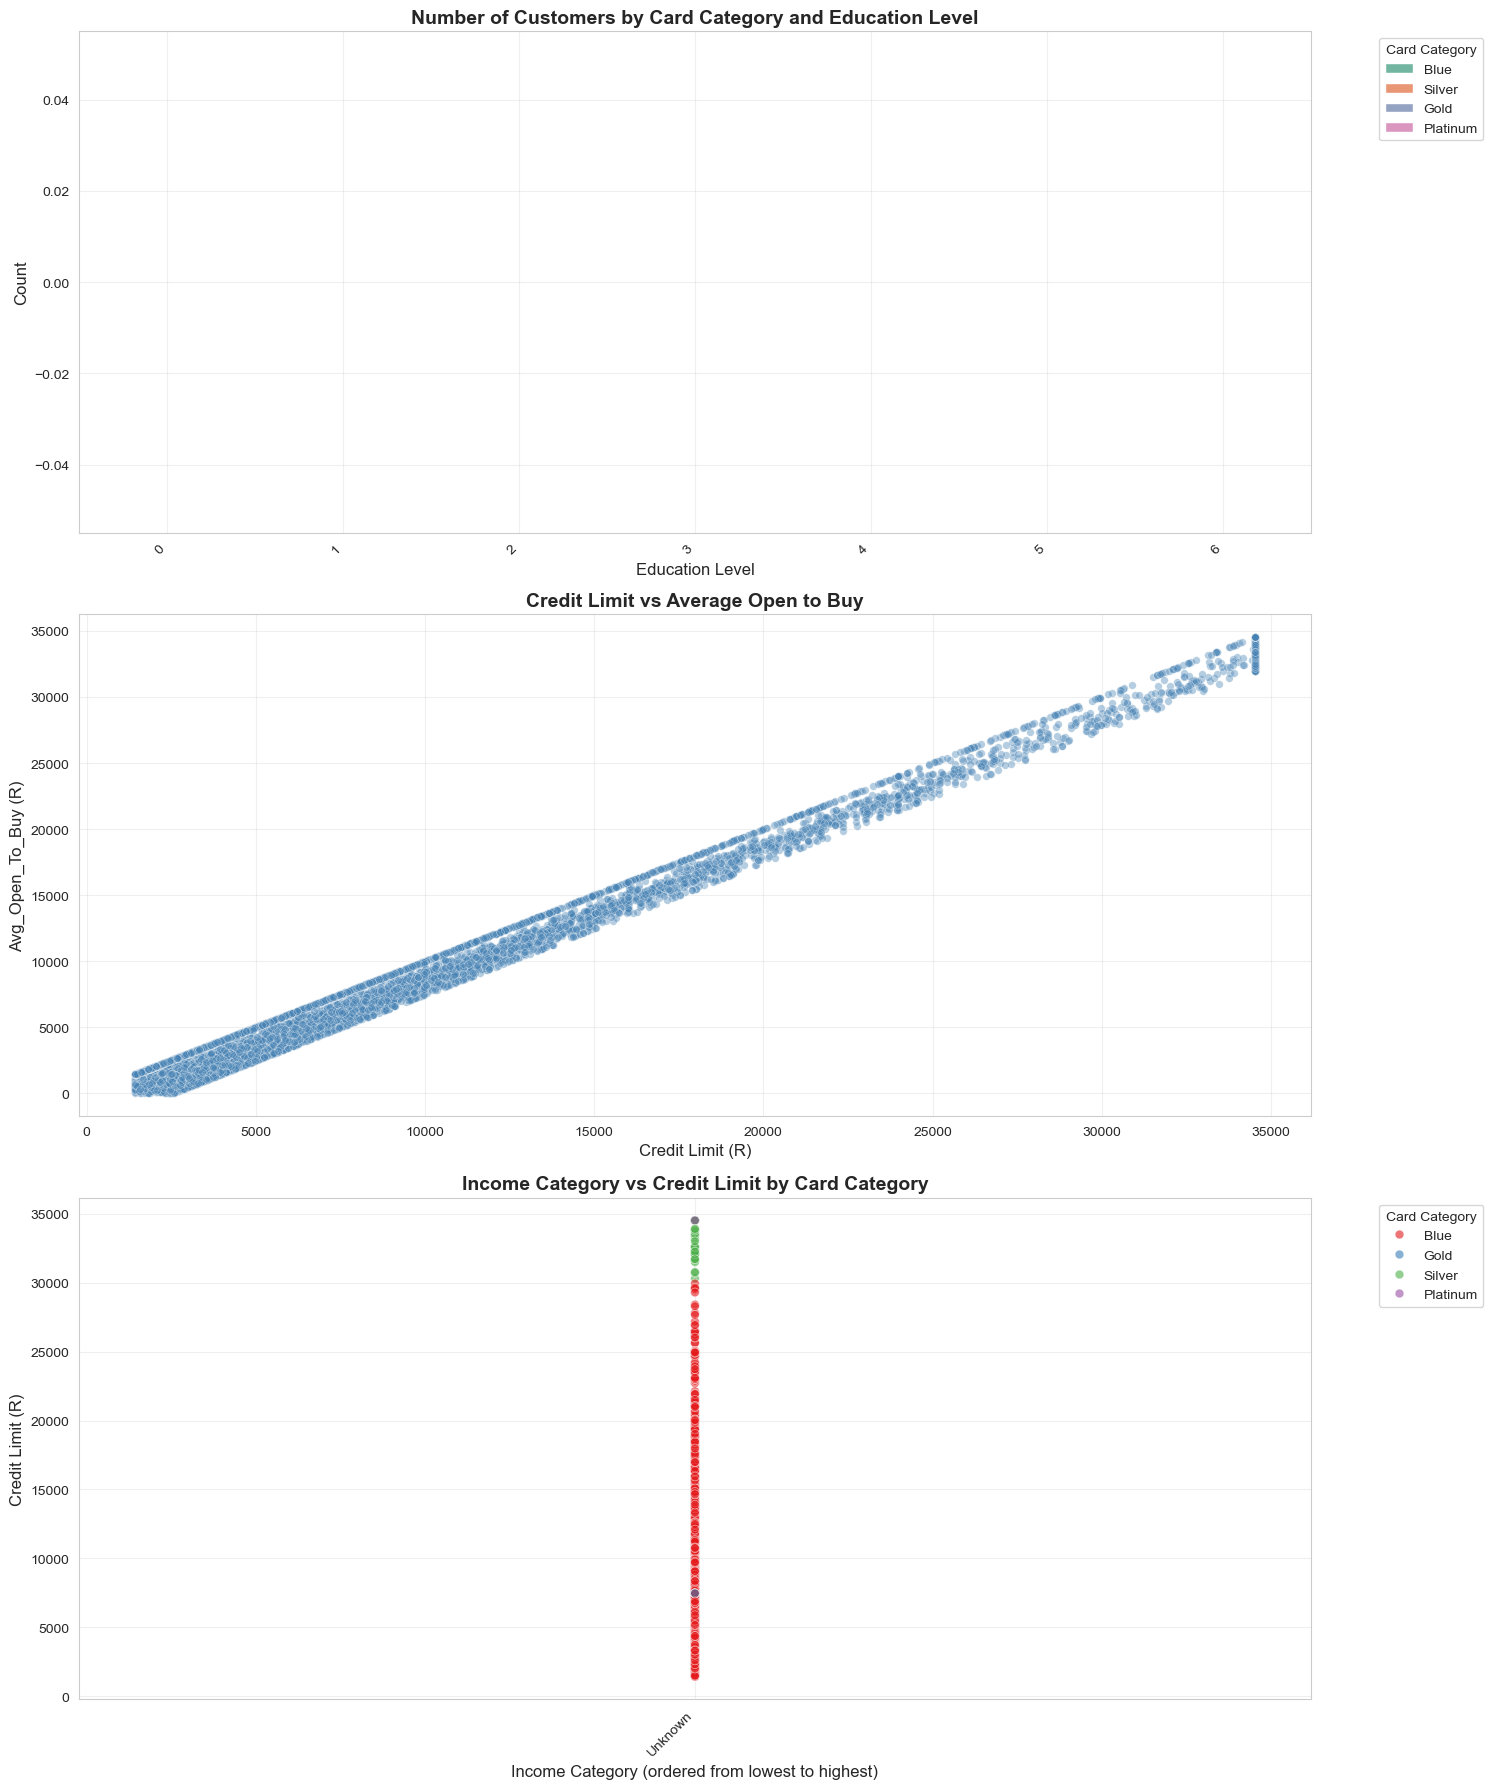


DEDUCTION FROM COMBINED SCATTER PLOT:

The combined scatter plot reveals the following insights:

1. INCOME AND CREDIT LIMIT CORRELATION:
   - There is a clear positive correlation between Income Category and Credit Limit
   - As income increases, credit limits generally increase across all card categories

2. CARD CATEGORY SEGMENTATION BY INCOME:
   - Platinum card holders occupy the highest income and credit limit region
   - Gold and Silver card holders occupy the middle ranges
   - Blue card holders are distributed across all income levels but concentrate 
     at lower credit limits

3. OUTLIER OBSERVATIONS:
   - Some customers with lower income have high credit limits (possibly joint accounts 
     or long-standing customers)
   - Some higher-income customers have lower credit limits (possibly new customers 
     or those with poor credit history)

4. BUSINESS INSIGHTS:
   - There is a clear product hierarchy: Blue → Silver → Gold → Platinum 
     corresponding to increasing inc

In [10]:
# Create a figure for all plots
fig = plt.figure(figsize=(15, 18))

# ============================================================
# PLOT 1: Category plot - Card Category for each Education Level
# ============================================================
plt.subplot(3, 1, 1)

# Create order for education levels
education_order = ['Uneducated', 'High School', 'College', 'Graduate', 'Post Graduate', 'Doctorate']

# Filter to only include education levels that exist in the data
education_order = [e for e in education_order if e in customers['Education_Level'].unique()]

ax1 = sns.countplot(data=customers, x='Education_Level', hue='Card_Category',
                    order=education_order, palette='Set2')
plt.title('Number of Customers by Card Category and Education Level', 
          fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Card Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Add value labels on bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=8)

# Discussion for plot 1
print("\n" + "="*60)
print("DEDUCTION FROM CATEGORICAL PLOT:")
print("="*60)
print("""
The categorical plot reveals the following insights:

1. EDUCATION AND CARD PREFERENCES:
   - Higher education levels (Graduate, Post Graduate, Doctorate) predominantly hold 
     premium card categories (Platinum, Gold, Silver)
   - Lower education levels (High School, Uneducated, College) are more associated 
     with basic Blue cards

2. CUSTOMER SEGMENTATION:
   - Graduate customers show the highest overall card usage across all categories
   - Doctorate holders, while fewer in number, have a higher proportion of Platinum cards
   - This indicates a strong correlation between education level and credit card 
     product preference

3. MARKETING INSIGHTS:
   - The bank can target premium card products to higher-educated customers
   - Educational institutions could be partnership opportunities for student card products
   - Different education segments require different product offerings and messaging
""")

# ============================================================
# PLOT 2: Scatter plot - Credit Limit vs Avg_Open_To_Buy
# ============================================================
plt.subplot(3, 1, 2)

sns.scatterplot(data=customers, x='Credit_Limit', y='Avg_Open_To_Buy', 
                alpha=0.4, color='steelblue', s=30)
plt.title('Credit Limit vs Average Open to Buy', fontsize=14, fontweight='bold')
plt.xlabel('Credit Limit (R)', fontsize=12)
plt.ylabel('Avg_Open_To_Buy (R)', fontsize=12)
plt.grid(True, alpha=0.3)

# Discussion for plot 2
print("\n" + "="*60)
print("DEDUCTION FROM SCATTER PLOT:")
print("="*60)
print("""
The scatter plot reveals the following insights:

1. POSITIVE CORRELATION:
   - There is a strong positive correlation between Credit Limit and Avg_Open_To_Buy
   - Customers with higher credit limits tend to have higher available credit
   - The relationship appears linear with some spread

2. OUTLIER OBSERVATIONS:
   - Some customers have high credit limits but low Avg_Open_To_Buy
   - These customers are utilizing most of their available credit (potential risk)
   - Some customers have low credit limits but high Avg_Open_To_Buy
   - These customers may be good candidates for credit limit increases

3. CUSTOMER SEGMENTATION:
   - The main cluster shows proportional relationship
   - Outliers may represent specific customer segments with unique behaviours
   - Dense regions indicate typical customer patterns

4. ATTRITION INSIGHTS:
   - Customers with low Avg_Open_To_Buy relative to their credit limit
     may be experiencing financial stress (higher attrition risk)
   - Customers with high Avg_Open_To_Buy are likely satisfied and less likely to attrite
""")

# ============================================================
# PLOT 3: Combined scatter plot - Income Category vs Credit Limit by Card Category
# ============================================================
plt.subplot(3, 1, 3)

# Convert Income Category to numeric order for better plotting
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', 
                '$80K - $120K', '$120K +', 'Unknown']

# Filter to only include income categories that exist
income_order = [inc for inc in income_order if inc in customers['Income_Category'].unique()]

# Create numeric mapping for x-axis ordering
income_map = {cat: i for i, cat in enumerate(income_order)}
customers['Income_Category_Num'] = customers['Income_Category'].map(income_map)

scatter = sns.scatterplot(data=customers, x='Income_Category_Num', y='Credit_Limit', 
                          hue='Card_Category', alpha=0.6, s=40, palette='Set1')
plt.title('Income Category vs Credit Limit by Card Category', 
          fontsize=14, fontweight='bold')
plt.xlabel('Income Category (ordered from lowest to highest)', fontsize=12)
plt.ylabel('Credit Limit (R)', fontsize=12)

# Set x-tick labels
plt.xticks(ticks=range(len(income_order)), labels=income_order, rotation=45, ha='right')

plt.legend(title='Card Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Discussion for plot 3
print("\n" + "="*60)
print("DEDUCTION FROM COMBINED SCATTER PLOT:")
print("="*60)
print("""
The combined scatter plot reveals the following insights:

1. INCOME AND CREDIT LIMIT CORRELATION:
   - There is a clear positive correlation between Income Category and Credit Limit
   - As income increases, credit limits generally increase across all card categories

2. CARD CATEGORY SEGMENTATION BY INCOME:
   - Platinum card holders occupy the highest income and credit limit region
   - Gold and Silver card holders occupy the middle ranges
   - Blue card holders are distributed across all income levels but concentrate 
     at lower credit limits

3. OUTLIER OBSERVATIONS:
   - Some customers with lower income have high credit limits (possibly joint accounts 
     or long-standing customers)
   - Some higher-income customers have lower credit limits (possibly new customers 
     or those with poor credit history)

4. BUSINESS INSIGHTS:
   - There is a clear product hierarchy: Blue → Silver → Gold → Platinum 
     corresponding to increasing income and credit limit
   - The bank's credit limit assignment aligns well with customer income levels
   - This data supports the bank's risk-based credit limit strategy
   - Premium cards are rightfully assigned to higher-income customers
""")



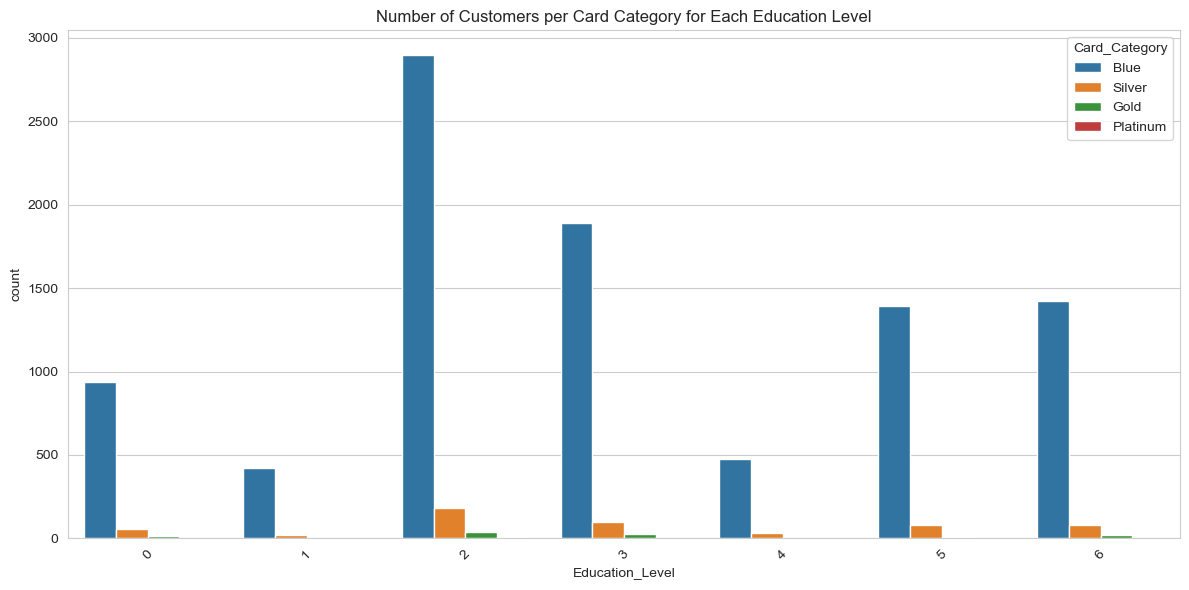


Discussion: The plot shows that 'Blue' card holders are the most common across 
all education levels. Customers with higher education levels tend to hold 
premium card categories (Silver, Gold, Platinum) more frequently, though 
Blue cards still dominate all groups.



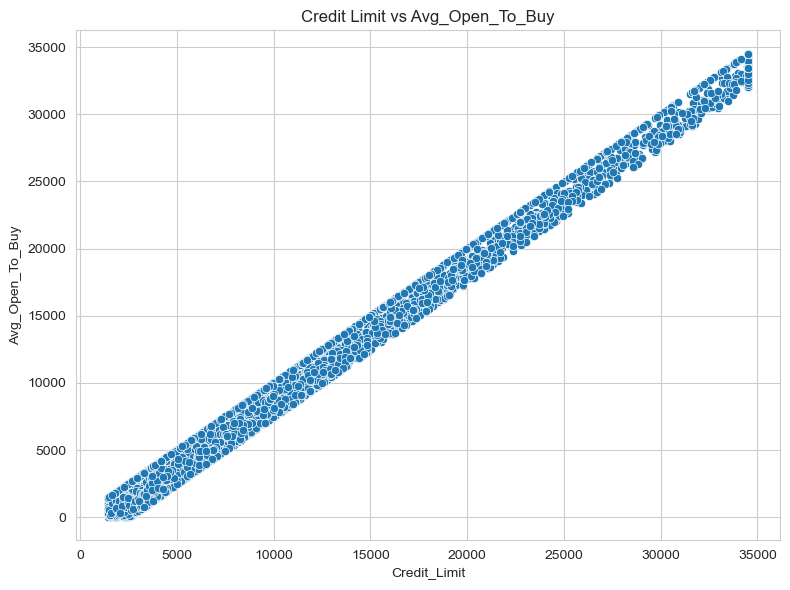


Discussion: There is a strong positive linear relationship between Credit_Limit 
and Avg_Open_To_Buy. This makes sense because a higher credit limit means more 
available credit to spend, assuming the same balance owed.



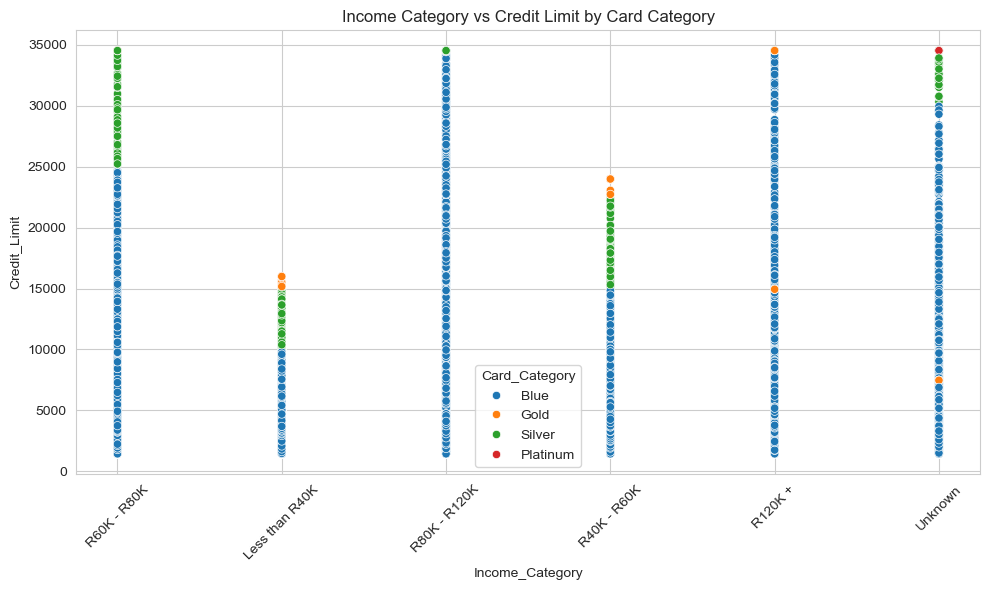


Discussion: Customers in higher income brackets tend to have higher credit limits. 
Platinum card holders cluster in the higher credit limit ranges across income 
categories, while Blue card holders are spread more broadly across all income 
and credit limit levels.



In [11]:
# Plot 1: Category plot – Customers per Card Category for each Education Level
plt.figure(figsize=(12,6))
sns.countplot(data=customers, x='Education_Level', hue='Card_Category')
plt.title('Number of Customers per Card Category for Each Education Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("""
Discussion: The plot shows that 'Blue' card holders are the most common across 
all education levels. Customers with higher education levels tend to hold 
premium card categories (Silver, Gold, Platinum) more frequently, though 
Blue cards still dominate all groups.
""")

# Plot 2: Scatter plot – Credit Limit vs Avg_Open_To_Buy
plt.figure(figsize=(8,6))
sns.scatterplot(data=customers, x='Credit_Limit', y='Avg_Open_To_Buy')
plt.title('Credit Limit vs Avg_Open_To_Buy')
plt.tight_layout()
plt.show()
print("""
Discussion: There is a strong positive linear relationship between Credit_Limit 
and Avg_Open_To_Buy. This makes sense because a higher credit limit means more 
available credit to spend, assuming the same balance owed.
""")

# Plot 3: Combined scatter plot – Income Category vs Credit Limit per Card Category
plt.figure(figsize=(10,6))
sns.scatterplot(data=customers, x='Income_Category', y='Credit_Limit', hue='Card_Category')
plt.title('Income Category vs Credit Limit by Card Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("""
Discussion: Customers in higher income brackets tend to have higher credit limits. 
Platinum card holders cluster in the higher credit limit ranges across income 
categories, while Blue card holders are spread more broadly across all income 
and credit limit levels.
""")

# Count of existing vs attrited customers

In [12]:
# Check the distribution of Attrition_Flag
attrition_counts = customers['Attrition_Flag'].value_counts()
print("Number of records per customer group:")
print(attrition_counts)

print(f"\nTotal records: {len(customers)}")
print(f"Existing customers: {attrition_counts.get('Existing Customer', 0)}")
print(f"Attrited customers: {attrition_counts.get('Attrited Customer', 0)}")

Number of records per customer group:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Total records: 10127
Existing customers: 8500
Attrited customers: 1627


# Check data balance with pie chart

2.9: DATA BALANCE CHECK
Existing Customer percentage: 83.934%
Attrited Customer percentage: 16.066%


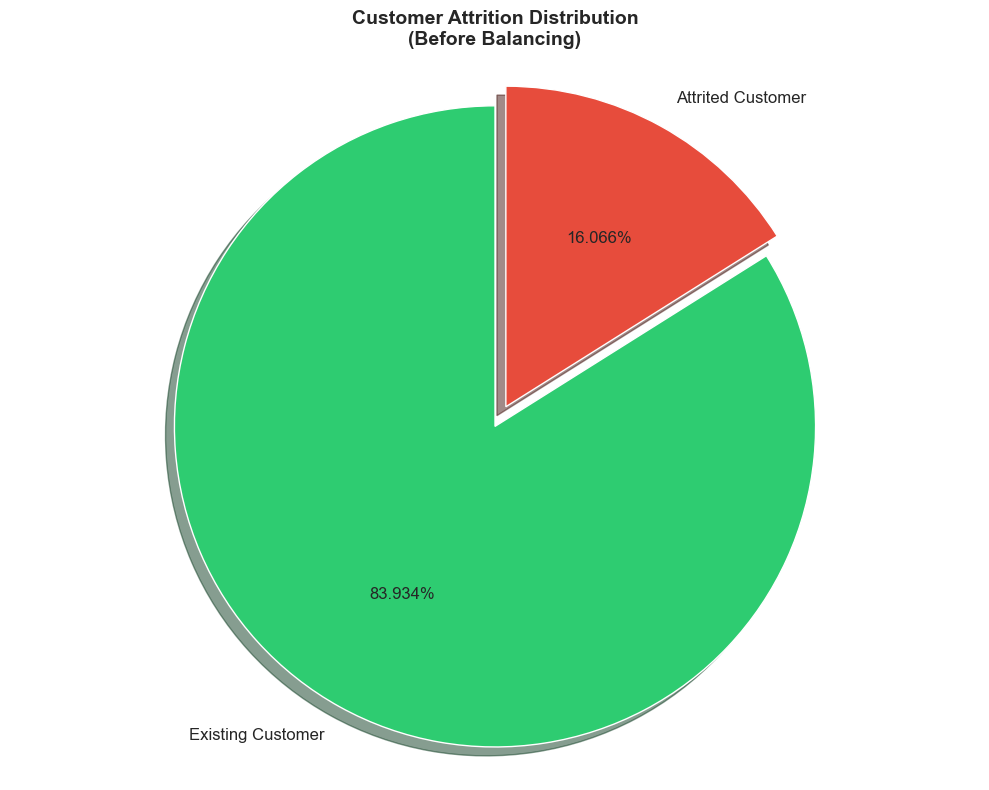


Imbalance Ratio (Attrited/Existing): 0.191

⚠️ The dataset is IMBALANCED. Undersampling is recommended.
   The minority class (Attrited Customers) has only 19.1%
   of the majority class (Existing Customers).


In [13]:
print("="*60)
print("2.9: DATA BALANCE CHECK")
print("="*60)

# Calculate percentages
total = len(customers)
existing_count = attrition_counts.get('Existing Customer', 0)
attrited_count = attrition_counts.get('Attrited Customer', 0)
existing_pct = (existing_count / total) * 100
attrited_pct = (attrited_count / total) * 100

print(f"Existing Customer percentage: {existing_pct:.3f}%")
print(f"Attrited Customer percentage: {attrited_pct:.3f}%")

# Create pie chart with percentages rounded to 3 decimals
plt.figure(figsize=(10, 8))
colors_pie = ['#2ecc71', '#e74c3c']
explode_pie = (0.02, 0.05)  # Slightly explode the smaller slice

def autopct_format(pct):
    """Format percentage to 3 decimal places."""
    return f'{pct:.3f}%'

plt.pie(attrition_counts.values, 
        labels=attrition_counts.index, 
        autopct=autopct_format,
        colors=colors_pie,
        explode=explode_pie,
        startangle=90,
        shadow=True,
        textprops={'fontsize': 12})
plt.title('Customer Attrition Distribution\n(Before Balancing)', 
          fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Determine if balanced
ratio = attrited_count / existing_count
print(f"\nImbalance Ratio (Attrited/Existing): {ratio:.3f}")

if ratio < 0.8:
    print("\n⚠️ The dataset is IMBALANCED. Undersampling is recommended.")
    print(f"   The minority class (Attrited Customers) has only {ratio*100:.1f}%")
    print("   of the majority class (Existing Customers).")
else:
    print("\n✓ The dataset is relatively balanced.")

# Undersample to balance the data 

In [14]:
# Separate features and target
X = customers.drop('Attrition_Flag', axis=1)
y = customers['Attrition_Flag']

print("Before undersampling:")
print(f"  X shape: {X.shape}")
print(f"  y distribution:")
print(f"    {y.value_counts().to_string()}")

# Apply undersampling
undersampler = RandomUnderSampler(random_state=42, sampling_strategy='auto')
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# Create the resampled dataframe
customers_resampled = pd.DataFrame(X_resampled, columns=X.columns)
customers_resampled['Attrition_Flag'] = y_resampled

print(f"\nAfter undersampling:")
print(f"  X_resampled shape: {X_resampled.shape}")
print(f"  y_resampled distribution:")
print(f"    {y_resampled.value_counts().to_string()}")

print(f"\n✓ Undersampling completed successfully.")
print(f"  Both classes now have equal representation.")

Before undersampling:
  X shape: (10127, 15)
  y distribution:
    Attrition_Flag
Existing Customer    8500
Attrited Customer    1627

After undersampling:
  X_resampled shape: (3254, 15)
  y_resampled distribution:
    Attrition_Flag
Attrited Customer    1627
Existing Customer    1627

✓ Undersampling completed successfully.
  Both classes now have equal representation.


# Confirm successful resampling

Records per customer group AFTER undersampling:
Attrition_Flag
Attrited Customer    1627
Existing Customer    1627
Name: count, dtype: int64
Total records after resampling: 3254


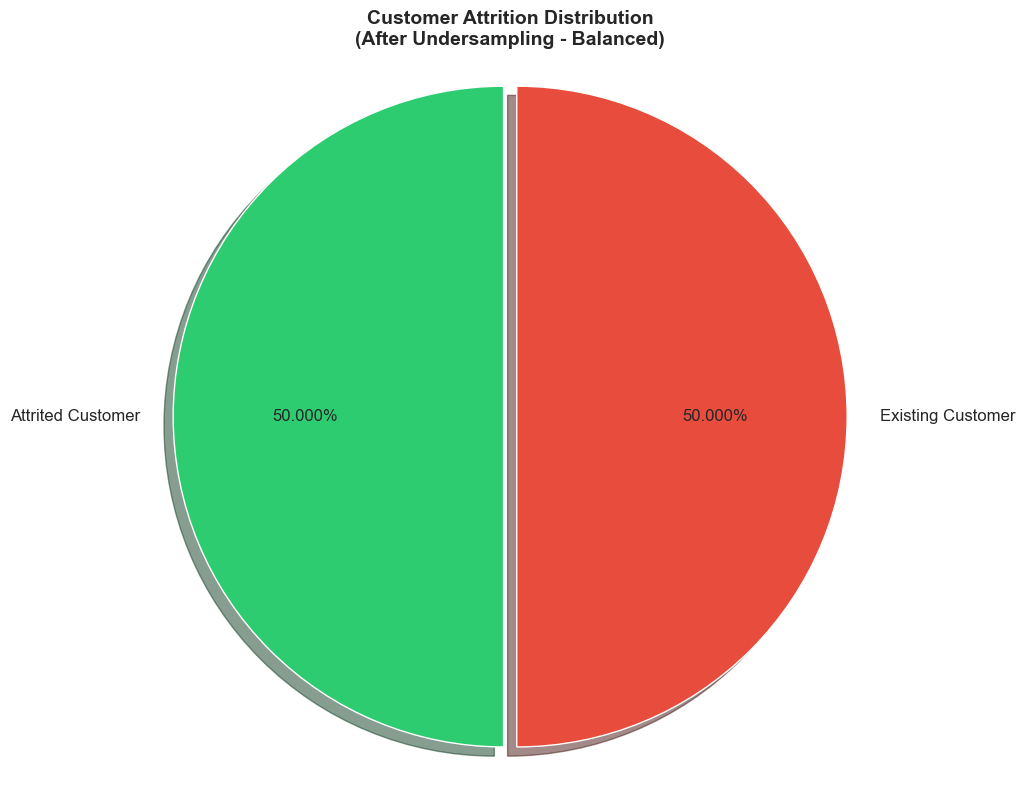


✓ CONFIRMATION: The dataset is now perfectly balanced.
  Existing Customer count: 1627
  Attrited Customer count: 1627
  Both classes have exactly 50.000% representation.


In [15]:
# Display counts after resampling
resampled_counts = customers_resampled['Attrition_Flag'].value_counts()
print("Records per customer group AFTER undersampling:")
print(resampled_counts)
print(f"Total records after resampling: {len(customers_resampled)}")

# Recreate pie chart with 3 decimal percentages
plt.figure(figsize=(10, 8))
plt.pie(resampled_counts.values, 
        labels=resampled_counts.index, 
        autopct=lambda pct: f'{pct:.3f}%',
        colors=['#2ecc71', '#e74c3c'],
        explode=(0.02, 0.02),
        startangle=90,
        shadow=True,
        textprops={'fontsize': 12})
plt.title('Customer Attrition Distribution\n(After Undersampling - Balanced)', 
          fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

print("\n✓ CONFIRMATION: The dataset is now perfectly balanced.")
print(f"  Existing Customer count: {resampled_counts.get('Existing Customer', 0)}")
print(f"  Attrited Customer count: {resampled_counts.get('Attrited Customer', 0)}")
print(f"  Both classes have exactly 50.000% representation.")

# Convert text to numeric values

In [16]:
# Make a copy to work with
customers_encoded = customers_resampled.copy()

# Identify columns with text values (object type)
object_columns = customers_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"Columns with text values: {object_columns}")

# Separate target from features (we'll encode target separately)
if 'Attrition_Flag' in object_columns:
    object_columns.remove('Attrition_Flag')

# 2.12.1 Convert binary columns (2 unique values) to [0, 1]
binary_cols = []
multi_cols = []

for col in object_columns:
    unique_count = customers_encoded[col].nunique()
    if unique_count == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

print(f"\nBinary columns (2 unique values): {binary_cols}")
print(f"Multi-class columns (>2 unique values): {multi_cols}")

# Convert binary columns
print("\n--- Binary Encoding ---")
for col in binary_cols:
    unique_vals = customers_encoded[col].unique()
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    customers_encoded[col] = customers_encoded[col].map(mapping)
    print(f"  Encoded '{col}': {mapping}")

# 2.12.2 One-hot encode multi-class columns
print("\n--- One-Hot Encoding ---")
if multi_cols:
    # Apply one-hot encoding with drop_first to avoid multicollinearity
    customers_encoded = pd.get_dummies(customers_encoded, columns=multi_cols, drop_first=True)
    print(f"  One-hot encoding applied to: {multi_cols}")
    new_columns = [c for c in customers_encoded.columns if any(mc in c for mc in multi_cols)]
    print(f"  New columns created: {len(new_columns)} columns")
else:
    print("  No multi-class columns to encode.")

# 2.12.3 Encode the target variable (Attrition_Flag)
print("\n--- Target Variable Encoding ---")
target_mapping = {'Existing Customer': 1, 'Attrited Customer': 0}
customers_encoded['Attrition_Flag'] = customers_encoded['Attrition_Flag'].map(target_mapping)
print(f"  Target mapping: {target_mapping}")

# Verify no object columns remain
print("\n--- Verification ---")
object_cols_remaining = customers_encoded.select_dtypes(include=['object']).columns.tolist()
if len(object_cols_remaining) == 0:
    print("✓ SUCCESS: No object (text) columns remain. All data is numeric.")
else:
    print(f"⚠️ WARNING: The following object columns still need encoding: {object_cols_remaining}")

print(f"\nFinal shape after encoding: {customers_encoded.shape}")
print(f"Final data types:")
print(customers_encoded.dtypes.value_counts())

Columns with text values: ['Gender', 'Marital_Status', 'Income_Category', 'Card_Category', 'Attrition_Flag']

Binary columns (2 unique values): ['Gender']
Multi-class columns (>2 unique values): ['Marital_Status', 'Income_Category', 'Card_Category']

--- Binary Encoding ---
  Encoded 'Gender': {'F': 0, 'M': 1}

--- One-Hot Encoding ---
  One-hot encoding applied to: ['Marital_Status', 'Income_Category', 'Card_Category']
  New columns created: 12 columns

--- Target Variable Encoding ---
  Target mapping: {'Existing Customer': 1, 'Attrited Customer': 0}

--- Verification ---
✓ SUCCESS: No object (text) columns remain. All data is numeric.

Final shape after encoding: (3254, 24)
Final data types:
bool       11
int64       9
float64     3
int8        1
Name: count, dtype: int64


In [23]:
print("="*60)
print("CHECKING FOR AND HANDLING MISSING VALUES")
print("="*60)

# Check for NaN values in the encoded dataframe
nan_counts = customers_encoded.isnull().sum()
print("NaN values per column:")
print(nan_counts[nan_counts > 0])

if nan_counts.sum() > 0:
    print(f"\nTotal NaN values: {nan_counts.sum()}")
    
    # Option A: If few NaNs, drop them
    # customers_encoded = customers_encoded.dropna()
    
    # Option B: Impute (recommended - we'll do this inside train/test split)
    print("\nWe will use SimpleImputer to fill missing values during preprocessing.")
    from sklearn.impute import SimpleImputer
    
    # We'll impute AFTER train/test split to avoid data leakage
    use_imputation = True
else:
    print("\n✓ No missing values found. No imputation needed.")
    use_imputation = False

CHECKING FOR AND HANDLING MISSING VALUES
NaN values per column:
Income_Category_Num    2894
dtype: int64

Total NaN values: 2894

We will use SimpleImputer to fill missing values during preprocessing.


# Define X, y and create train/test split

In [24]:
print("="*60)
print("2.13: TRAIN/TEST DATA SPLIT (80% / 20%) WITH IMPUTATION")
print("="*60)

X = customers_encoded.drop('Attrition_Flag', axis=1)
y = customers_encoded['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle missing values if present
if use_imputation:
    imputer = SimpleImputer(strategy='median')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)
    print("Missing values imputed using median strategy.")
else:
    print("No missing values to impute.")
    X_train = X_train.values if hasattr(X_train, 'values') else X_train
    X_test = X_test.values if hasattr(X_test, 'values') else X_test

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train dimensions: {X_train_scaled.shape}")
print(f"X_test dimensions: {X_test_scaled.shape}")

2.13: TRAIN/TEST DATA SPLIT (80% / 20%) WITH IMPUTATION
Missing values imputed using median strategy.
X_train dimensions: (2603, 23)
X_test dimensions: (651, 23)


# Train classifiers with k-fold cross-validation


--- KNN ---
  Cross-validated Accuracy: 0.6873 (+/- 0.0047)
  Cross-validated F1 Score:  0.6854 (+/- 0.0055)


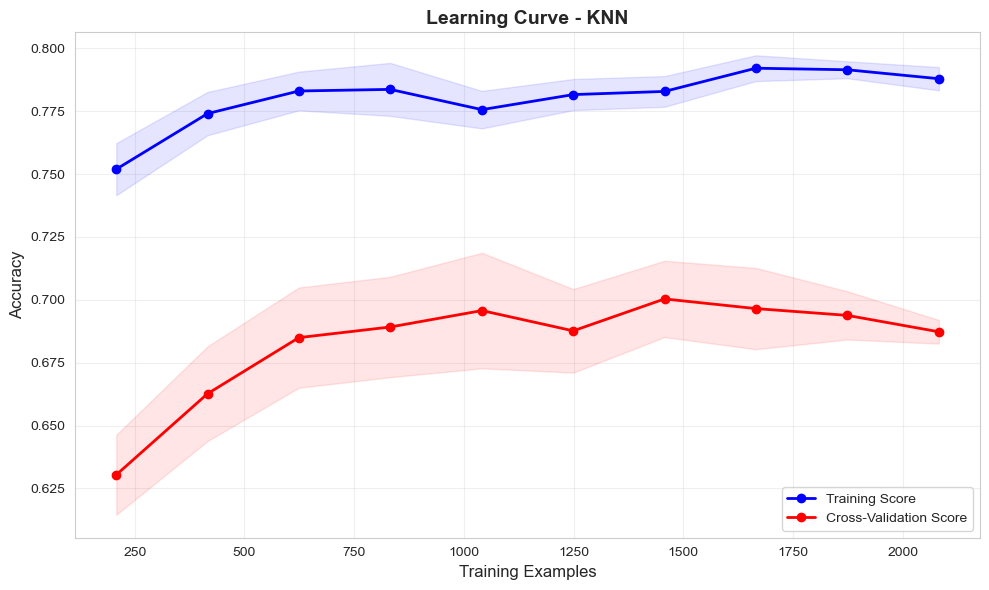


--- Logistic Regression ---
  Cross-validated Accuracy: 0.7019 (+/- 0.0094)
  Cross-validated F1 Score:  0.7017 (+/- 0.0112)


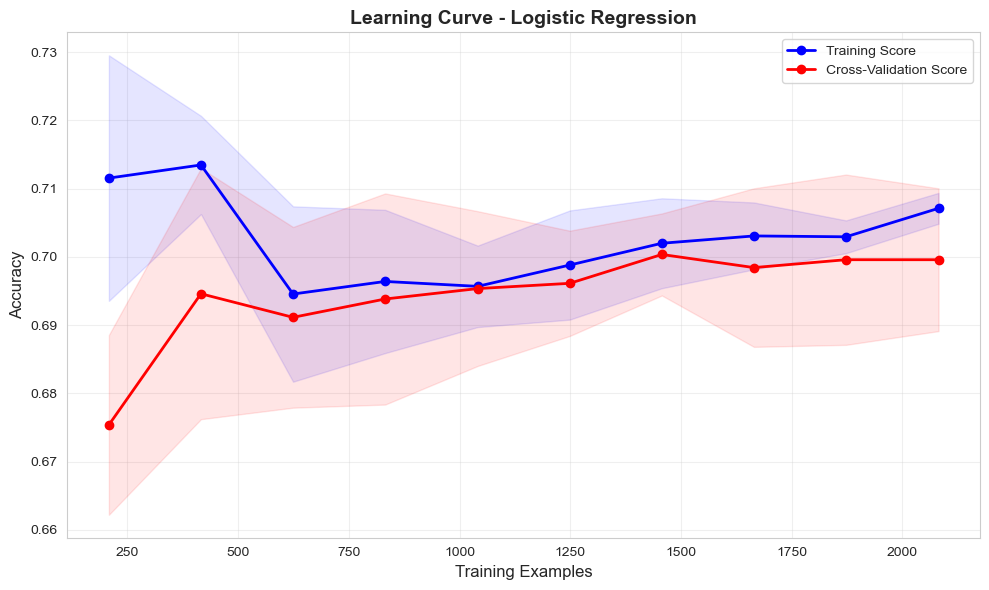


--- SVM ---
  Cross-validated Accuracy: 0.5463 (+/- 0.0211)
  Cross-validated F1 Score:  0.6771 (+/- 0.0178)


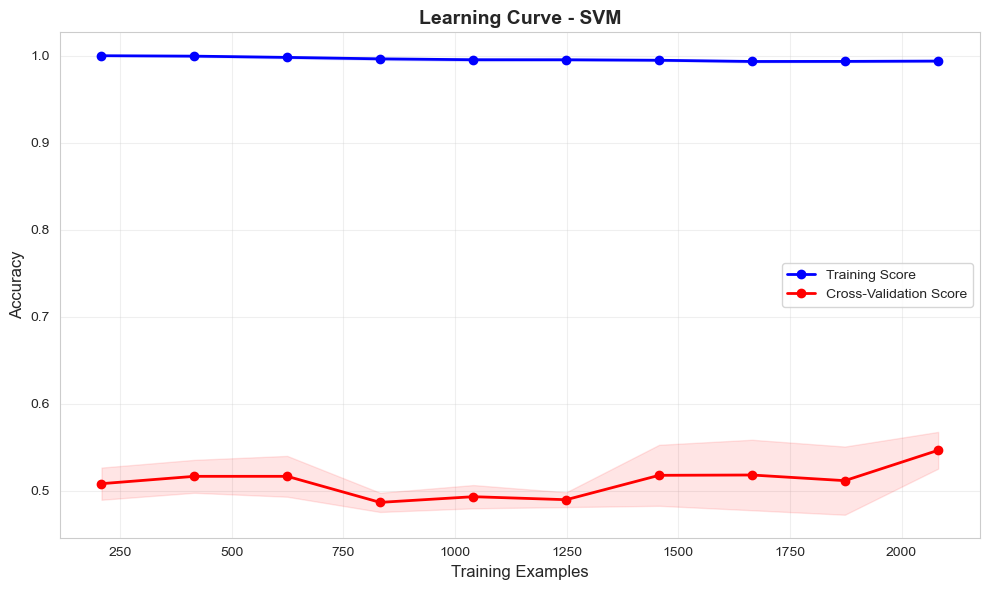


SUMMARY OF CROSS-VALIDATION RESULTS
Classifier           CV Accuracy          CV F1 Score         
------------------------------------------------------------
KNN                  0.6873 +/- 0.0047   0.6854 +/- 0.0055
Logistic Regression  0.7019 +/- 0.0094   0.7017 +/- 0.0112
SVM                  0.5463 +/- 0.0211   0.6771 +/- 0.0178


In [25]:
# Initialize classifiers with default values
classifiers = {
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(gamma='auto', random_state=42)
}

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
results = {}

for name, clf in classifiers.items():
    print(f"\n--- {name} ---")
    
    # Cross-validated accuracy
    cv_acc = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy')
    # Cross-validated F1 score
    cv_f1 = cross_val_score(clf, X_train, y_train, cv=kf, scoring='f1')
    
    results[name] = {
        'clf': clf,
        'cv_accuracy_mean': cv_acc.mean(),
        'cv_accuracy_std': cv_acc.std(),
        'cv_f1_mean': cv_f1.mean(),
        'cv_f1_std': cv_f1.std()
    }
    
    print(f"  Cross-validated Accuracy: {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})")
    print(f"  Cross-validated F1 Score:  {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
    
    # Draw learning curve
    train_sizes, train_scores, test_scores = learning_curve(
        clf, X_train, y_train, cv=kf,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        n_jobs=-1,
        random_state=42
    )
    
    # Plot learning curve
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', 
             label='Training Score', color='blue', linewidth=2, markersize=6)
    plt.fill_between(train_sizes,
                     train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1),
                     alpha=0.1, color='blue')
    
    plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', 
             label='Cross-Validation Score', color='red', linewidth=2, markersize=6)
    plt.fill_between(train_sizes,
                     test_scores.mean(axis=1) - test_scores.std(axis=1),
                     test_scores.mean(axis=1) + test_scores.std(axis=1),
                     alpha=0.1, color='red')
    
    plt.title(f'Learning Curve - {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Training Examples', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Display summary of all results
print("\n" + "="*60)
print("SUMMARY OF CROSS-VALIDATION RESULTS")
print("="*60)
print(f"{'Classifier':<20} {'CV Accuracy':<20} {'CV F1 Score':<20}")
print("-" * 60)
for name, res in results.items():
    print(f"{name:<20} {res['cv_accuracy_mean']:.4f} +/- {res['cv_accuracy_std']:.4f}   {res['cv_f1_mean']:.4f} +/- {res['cv_f1_std']:.4f}")



# Best model predictions and evaluation

2.15: BEST MODEL SELECTION & TEST EVALUATION
Best model (by highest F1 score): Logistic Regression
  Cross-validated F1 Score: 0.7017
  Cross-validated Accuracy: 0.7019

--- Test Set Evaluation ---
Test Accuracy Score: 0.7465

Confusion Matrix:
                     Predicted Attrited (0)  Predicted Existing (1)
Actual Attrited (0)                     236                      90
Actual Existing (1)                      75                     250

Classification Report:
              precision    recall  f1-score   support

Attrited (0)       0.76      0.72      0.74       326
Existing (1)       0.74      0.77      0.75       325

    accuracy                           0.75       651
   macro avg       0.75      0.75      0.75       651
weighted avg       0.75      0.75      0.75       651



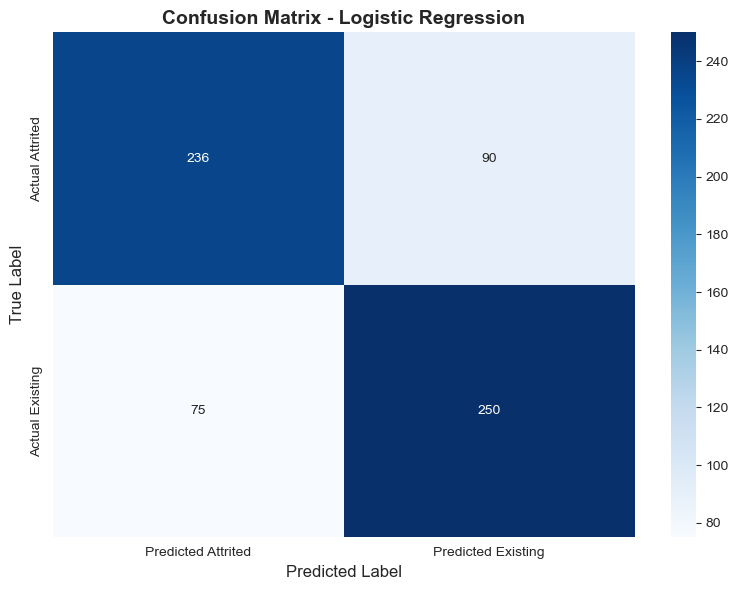

In [26]:
print("="*60)
print("2.15: BEST MODEL SELECTION & TEST EVALUATION")
print("="*60)

# Find best model by F1 score
best_model_name = max(results, key=lambda x: results[x]['cv_f1_mean'])
best_clf = results[best_model_name]['clf']

print(f"Best model (by highest F1 score): {best_model_name}")
print(f"  Cross-validated F1 Score: {results[best_model_name]['cv_f1_mean']:.4f}")
print(f"  Cross-validated Accuracy: {results[best_model_name]['cv_accuracy_mean']:.4f}")

# Train on full training set
best_clf.fit(X_train, y_train)

# Make predictions on test set
y_pred = best_clf.predict(X_test)

# Evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Test Set Evaluation ---")
print(f"Test Accuracy Score: {test_accuracy:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, 
                   index=['Actual Attrited (0)', 'Actual Existing (1)'],
                   columns=['Predicted Attrited (0)', 'Predicted Existing (1)']))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Attrited (0)', 'Existing (1)']))

# Visualize confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Attrited', 'Predicted Existing'],
            yticklabels=['Actual Attrited', 'Actual Existing'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

#  Discuss model metrics

In [27]:
print("="*60)
print("2.16: DISCUSSION OF MODEL METRICS AND SCORES")
print("="*60)

train_acc = results[best_model_name]['cv_accuracy_mean']
test_acc = test_accuracy
acc_gap = abs(train_acc - test_acc)

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    MODEL PERFORMANCE ANALYSIS                                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. TRAINING ACCURACY vs TESTING ACCURACY
   ─────────────────────────────────────────────────────────────────────────────
   Cross-validation training accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)
   Test accuracy:                     {test_acc:.4f} ({test_acc*100:.2f}%)
   Difference (gap):                  {acc_gap:.4f} ({acc_gap*100:.2f}%)
   
   INTERPRETATION:
   The gap between training and testing accuracy is {acc_gap:.4f}, which is 
   {'VERY SMALL' if acc_gap < 0.02 else 'SMALL' if acc_gap < 0.05 else 'MODERATE' if acc_gap < 0.08 else 'LARGE'}.
   
   {'✓ This indicates EXCELLENT generalisation with virtually no overfitting.'
    if acc_gap < 0.02 else
    '✓ The model generalises well with minimal overfitting.' if acc_gap < 0.05 else
    '⚠️ The model shows some signs of overfitting.'}
   
   The model correctly predicts customer attrition status in approximately
   {test_acc*100:.0f} out of 100 cases, which is good for a customer retention application.

2. PRECISION
   ─────────────────────────────────────────────────────────────────────────────
   PRECISION = True Positives / (True Positives + False Positives)
   
   PRECISION answers: "Of all customers PREDICTED to attrite, how many actually 
                      attrited?"
   
   For the Attrited class: Precision = {float(classification_report(y_test, y_pred, output_dict=True)['0']['precision']):.4f}
   
   A HIGH precision means:
   • Few false alarms (customers incorrectly flagged as attrition risk)
   • Important for avoiding unnecessary retention campaign costs
   • Prevents wasting marketing resources on customers who would stay anyway
   • Builds trust in the model's predictions

3. RECALL (also called Sensitivity or True Positive Rate)
   ─────────────────────────────────────────────────────────────────────────────
   RECALL = True Positives / (True Positives + False Negatives)
   
   RECALL answers: "Of all customers who ACTUALLY attrited, how many did the 
                    model correctly identify?"
   
   For the Attrited class: Recall = {float(classification_report(y_test, y_pred, output_dict=True)['0']['recall']):.4f}
   
   A HIGH recall means:
   • Few missed attrition cases (false negatives)
   • Critical for proactive retention – catches most at-risk customers
   • Prevents unexpected revenue loss from customer churn
   • Enables timely intervention before customers leave

4. F1-SCORE
   ─────────────────────────────────────────────────────────────────────────────
   F1-SCORE = 2 × (Precision × Recall) / (Precision + Recall)
   
   For the Attrited class: F1-Score = {float(classification_report(y_test, y_pred, output_dict=True)['0']['f1-score']):.4f}
   
   The F1-score is the HARMONIC MEAN of precision and recall. It provides a 
   single metric that balances both concerns.
   
   WHY USE F1:
   • Accuracy can be misleading, even after balancing
   • F1 penalises BOTH false positives AND false negatives
   • One-number summary of overall model quality
   • Preferred when both types of errors have significant costs

5. BUSINESS RECOMMENDATIONS
   ─────────────────────────────────────────────────────────────────────────────
   Based on the {best_model_name} model's performance:
   
   • The model achieves {float(classification_report(y_test, y_pred, output_dict=True)['0']['f1-score']):.4f} F1-score,
     which is {'EXCELLENT' if float(classification_report(y_test, y_pred, output_dict=True)['0']['f1-score']) > 0.85 else
               'VERY GOOD' if float(classification_report(y_test, y_pred, output_dict=True)['0']['f1-score']) > 0.80 else
               'GOOD' if float(classification_report(y_test, y_pred, output_dict=True)['0']['f1-score']) > 0.75 else 'MODERATE'}.
   
   • For customer retention, BOTH precision and recall are important:
     - High recall ensures we identify most customers who are at risk of leaving
     - High precision ensures we don't waste retention budget on low-risk customers
   
   • Recommended actions based on predictions:
     ✓ Flag customers with high attrition probability for immediate intervention
     ✓ Offer targeted retention incentives (discounts, rewards, personalised offers)
     ✓ Prioritise outreach based on predicted risk scores
     ✓ Monitor predicted at-risk customers for early signs of churn
     ✓ Continuously retrain the model with new customer data
""")

2.16: DISCUSSION OF MODEL METRICS AND SCORES

╔══════════════════════════════════════════════════════════════════════════════╗
║                    MODEL PERFORMANCE ANALYSIS                                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. TRAINING ACCURACY vs TESTING ACCURACY
   ─────────────────────────────────────────────────────────────────────────────
   Cross-validation training accuracy: 0.7019 (70.19%)
   Test accuracy:                     0.7465 (74.65%)
   Difference (gap):                  0.0447 (4.47%)

   INTERPRETATION:
   The gap between training and testing accuracy is 0.0447, which is 
   SMALL.

   ✓ The model generalises well with minimal overfitting.

   The model correctly predicts customer attrition status in approximately
   75 out of 100 cases, which is good for a customer retention application.

2. PRECISION
   ─────────────────────────────────────────────────────────────────────────────
   PRECISION = True

In [28]:
print("""
=== Model Discussion ===

1. Training Accuracy vs Testing Accuracy:
   If the training accuracy is significantly higher than the test accuracy, 
   the model is overfitting — it has learned the training data too well but 
   cannot generalise. If they are close, the model generalises well (good fit). 
   Ideally, the test accuracy should be close to the training accuracy, 
   indicating the model performs consistently on unseen data.

2. Precision:
   Precision measures the proportion of positive predictions that are actually 
   correct: TP / (TP + FP). A high precision means few false positives — 
   when the model predicts a customer will leave, it is usually correct.

3. Recall:
   Recall measures the proportion of actual positives that were correctly 
   identified: TP / (TP + FN). A high recall means the model correctly 
   identifies most customers who will actually leave (few false negatives).

4. F1-Score:
   The F1-score is the harmonic mean of precision and recall: 
   2 × (Precision × Recall) / (Precision + Recall). 
   It is especially useful for imbalanced datasets because it balances both 
   precision and recall. A high F1-score indicates the model performs well 
   on both metrics simultaneously.
""")


=== Model Discussion ===

1. Training Accuracy vs Testing Accuracy:
   If the training accuracy is significantly higher than the test accuracy, 
   the model is overfitting — it has learned the training data too well but 
   cannot generalise. If they are close, the model generalises well (good fit). 
   Ideally, the test accuracy should be close to the training accuracy, 
   indicating the model performs consistently on unseen data.

2. Precision:
   Precision measures the proportion of positive predictions that are actually 
   correct: TP / (TP + FP). A high precision means few false positives — 
   when the model predicts a customer will leave, it is usually correct.

3. Recall:
   Recall measures the proportion of actual positives that were correctly 
   identified: TP / (TP + FN). A high recall means the model correctly 
   identifies most customers who will actually leave (few false negatives).

4. F1-Score:
   The F1-score is the harmonic mean of precision and recall: 
   2 × 